# 作业 3：中证500指数增强组合以及灵活对冲策略初探

---

## 作业概述

基于线性组合优化的增强组合构建了市场中性组合和暴露一定多头敞口的灵活对冲策略
并在2021-12-31至2025-12-31区间进行了回测

### 核心成果

| 策略 | 夏普比率 | 最大回撤 | 年化收益率 | 年化波动率 |
|------|---------|---------|-----------|-----------|
| 基准指数 | -0.07 | -39.52% | 0.37% | 21.79% |
| 增强组合 | -0.41 | -59.99% | -8.81% | 26.08% |
| 完全对冲 | -1.24 | -47.62% | -13.98% | 12.84% |
| 动态对冲 | -0.80 | -38.40% | -8.54% | 13.21% |

动态对冲策略与完全对冲策略对比，夏普比率等指标表现更优；进一步与指增策略对比，最大回撤、年化收益率、年化波动率表现均优于指增策略。这表明动态对冲策略通过基差预测模型调整对冲比例，有效提升了策略表现。

注：本作业主要聚焦市场中性策略和灵活对冲策略的构建，对指增策略的构建仍有所欠缺。因此相信对指数增强组合的优化，本作业中的三个策略表现会更优异。

### 主要方法
构建基差预测模型，通过基差波动率、现货波动率、期货波动率预测调仓日基差波动率，并根据预测结果的历史分位确定对冲比例

### 后续目标
通过以下两步，试图使灵活对冲策略表现优于指数表现，吸引投资者投资。
1. 验证本作业中多头敞口暴露方法对不同指数增强策略的优化效果
2. 优化基差预测模型，提高模型表现（例如更换预测变量、使用非线性模型、调參等）


## Step 1：环境配置与库导入及参数设置

In [4]:
import pandas as pd
import numpy as np
import datetime
import cvxpy as cp
import matplotlib.pyplot as plt
import rqdatac as rq
from sklearn.linear_model import LinearRegression

# 初始化 rqdatac
rq.init()

print("环境配置完成，库导入成功！")


环境配置完成，库导入成功！


## Step 2：参数设置

In [5]:
# 核心参数
start_date = datetime.date(2021, 12, 31)
end_date = datetime.date(2025, 12, 31)
benchmark_index = '000905.XSHG'  # 中证500

# 因子列表
factor_list = ['profit_growth_ratio_ttm', 'return_on_equity_ttm', 'VOLT60', 'market_cap']
factor_weight = np.array([0.25, 0.25, 0.25, 0.25], dtype=float)

# 约束与回测参数
market_cap_tolerance = 0.1
min_listed_days = 180
initial_nav = 1000
risk_free_rate = 0.02

print("策略参数设置完成")
print(f"  时间范围: {start_date} 至 {end_date}")
print(f"  基准指数: {benchmark_index}")
print(f"  因子列表: {factor_list}")


策略参数设置完成
  时间范围: 2021-12-31 至 2025-12-31
  基准指数: 000905.XSHG
  因子列表: ['profit_growth_ratio_ttm', 'return_on_equity_ttm', 'VOLT60', 'market_cap']


## Step 3：多因子选股

In [6]:
def factor_normalization(df_factor, confidence_level=0.01):
    """
    因子截面标准化：MAD法去极值 + Z-Score标准化
    """
    df_norm = pd.DataFrame(index=df_factor.index, columns=df_factor.columns, dtype=float)
    
    for col in df_factor.columns:
        daily_factors = pd.to_numeric(df_factor[col], errors='coerce').dropna()
        if len(daily_factors) > 0:
            mean_val = np.mean(daily_factors)
            mad_val = np.median(np.abs(daily_factors - mean_val))
            if mad_val > 0:
                lower_bound = mean_val - 5 * mad_val
                upper_bound = mean_val + 5 * mad_val
                winsorized = np.clip(daily_factors, lower_bound, upper_bound)
                winsorized_mean = np.mean(winsorized)
                winsorized_std = np.std(winsorized)
                if winsorized_std > 0:
                    z_scores = (winsorized - winsorized_mean) / winsorized_std
                else:
                    z_scores = pd.Series(0.0, index=winsorized.index)
                df_norm.loc[z_scores.index, col] = z_scores
            else:
                df_norm.loc[daily_factors.index, col] = 0.0
    
    return df_norm

In [7]:
def get_rebalance_dates(start_date, end_date, freq='semiannual'):
    """
    生成调仓日期列表。
    freq: 'semiannual'/'h' 为每年6月和12月最后一个交易日；'monthly'/'m' 为每月最后一个交易日。
    """
    trading_dates = [pd.Timestamp(d).date() for d in rq.get_trading_dates(start_date, end_date)]
    trading_dates = [d for d in trading_dates if start_date <= d <= end_date]
    if not trading_dates:
        return []

    freq = freq.lower()
    if freq in {'monthly', 'm'}:
        buckets = {}
        for d in trading_dates:
            buckets[(d.year, d.month)] = d
        return sorted(buckets.values())

    if freq in {'semiannual', 'halfyear', 'h'}:
        rebalance_dates = []
        for year in range(start_date.year, end_date.year + 1):
            for month in [6, 12]:
                month_dates = [d for d in trading_dates if d.year == year and d.month == month]
                if month_dates:
                    rebalance_dates.append(month_dates[-1])
        return sorted(set(rebalance_dates))

    raise ValueError("freq 仅支持 'semiannual'/'h' 或 'monthly'/'m'")


In [8]:
def filter_stocks(val_date, min_listed_days=180):
    """
    全市场选股：剔除ST、上市不足min_listed_days天的股票
    """
    all_stocks = rq.all_instruments('CS')
    all_stocks = all_stocks[all_stocks['special_type'] == 'Normal'].copy()
    
    def safe_date_convert(date_str):
        try:
            if pd.isna(date_str) or date_str in ['0000-00-00', '2999-12-31', '']:
                return pd.NaT
            return pd.to_datetime(date_str, errors='coerce')
        except:
            return pd.NaT
    
    all_stocks['listed_date_dt'] = all_stocks['listed_date'].apply(safe_date_convert)
    all_stocks = all_stocks.dropna(subset=['listed_date_dt'])
    
    cutoff_date = pd.to_datetime(val_date) - pd.Timedelta(days=min_listed_days)
    all_stocks = all_stocks[all_stocks['listed_date_dt'] <= cutoff_date]
    
    return all_stocks['order_book_id'].tolist()

## Step 4：因子提取与行业分类

In [9]:
def port_factor(val_date, benchmark_index, factor_list, factor_weight):
    """
    提取股票池因子值、行业分类及指数权重
    """
    secList = filter_stocks(val_date)
    print(f"  股票池数量: {len(secList)}")
    
    df_factor = rq.get_factor(secList, factor_list, val_date, val_date)
    if isinstance(df_factor.index, pd.MultiIndex):
        if 'date' in df_factor.index.names:
            df_factor = df_factor.droplevel('date')
        else:
            df_factor = df_factor.droplevel(-1)
    df_factor = df_factor.dropna()
    print(f"  有效因子股票数量: {len(df_factor)}")
    
    df_norm = factor_normalization(df_factor, confidence_level=0.01)
    df_norm.columns = [f + "_norm" for f in df_norm.columns]
    df_factor = df_factor.join(df_norm)
    
    factor_list_norm = [f + "_norm" for f in factor_list]
    df_factor["zscore"] = (df_factor[factor_list_norm] * factor_weight).sum(axis=1)
    
    citics_industry = rq.get_instrument_industry(
        df_factor.index.tolist(), source='citics_2019', level=1, date=val_date, market='cn'
    )
    df_factor["citics_industry_code"] = citics_industry.first_industry_code
    df_factor["citics_industry_name"] = citics_industry.first_industry_name
    
    idx_weights_raw = rq.index_weights(benchmark_index, date=val_date)
    index_weights = pd.DataFrame({'weights': idx_weights_raw})
    
    idx_industry = rq.get_instrument_industry(
        index_weights.index.tolist(), source='citics_2019', level=1, date=val_date, market='cn'
    )
    index_weights["citics_industry_code"] = idx_industry.first_industry_code
    
    df_factor["index_weight"] = index_weights['weights'].reindex(df_factor.index).fillna(0)
    
    return df_factor, index_weights

## Step 5：cvxpy 线性优化组合构建

In [10]:
def optimizing_port(df_factor, index_weights, market_cap_tolerance=0.1):
    """
    cvxpy 线性优化构建中证500指数增强组合。
    若严格约束无可行解，回退到指数成分权重归一化，保证后续回测不中断。
    """
    df_factor = df_factor.dropna(subset=['citics_industry_code', 'market_cap_norm']).copy()
    if df_factor.empty:
        raise ValueError("因子数据为空，无法优化组合")

    X = df_factor["zscore"].values.astype(float)
    size_arr = df_factor["market_cap_norm"].values.astype(float)
    num = len(df_factor)

    total_weight = df_factor["index_weight"].sum()
    if total_weight > 0:
        component_weight = (df_factor["index_weight"] / total_weight).values.astype(float)
    else:
        component_weight = np.ones(num) / num

    idx_common = index_weights.index.intersection(df_factor.index)
    if len(idx_common) > 0:
        idx_mcap = df_factor.loc[idx_common, "market_cap_norm"]
        idx_w = index_weights.loc[idx_common, 'weights']
        index_size = (idx_mcap * idx_w).sum() / idx_w.sum() if idx_w.sum() > 0 else 0
    else:
        index_size = float(np.dot(component_weight, size_arr))

    H_dum = pd.get_dummies(df_factor.citics_industry_code)
    index_industry_weights = index_weights.groupby("citics_industry_code")["weights"].sum()
    common_industries = H_dum.columns.intersection(index_industry_weights.index)

    H = h = None
    if len(common_industries) > 0:
        H_dum = H_dum[common_industries]
        h = index_industry_weights.loc[common_industries].values.astype(float)
        h = h / h.sum()
        H = H_dum.values.astype(float)

    w = cp.Variable(num)
    objective = cp.Minimize(-cp.sum(cp.multiply(w, X)))
    constraints = [
        w >= 0,
        w <= 0.1,
        w - component_weight >= -0.05,
        w - component_weight <= 0.05,
        cp.sum(w) == 1,
        cp.sum(cp.multiply(w, size_arr)) - index_size <= market_cap_tolerance,
        cp.sum(cp.multiply(w, size_arr)) - index_size >= -market_cap_tolerance,
    ]
    if H is not None:
        constraints.append(H.T @ w == h)

    prob = cp.Problem(objective, constraints)
    try:
        prob.solve()
    except Exception as e:
        print(f"  求解异常: {e}")

    weight_value = w.value
    if weight_value is None:
        print("  优化未找到可行解，使用指数成分权重回退")
        weight_value = component_weight.copy()

    weight_value = np.asarray(weight_value, dtype=float)
    weight_value[weight_value < 1e-5] = 0
    weight_sum = weight_value.sum()
    if weight_sum <= 0:
        weight_value = component_weight.copy()
        weight_sum = weight_value.sum()
    weight_value = weight_value / weight_sum

    df_factor["market_weight"] = weight_value

    port_size = float(np.dot(weight_value, size_arr))
    print(f"  指数市值暴露: {index_size:.6f}, 组合市值暴露: {port_size:.6f}, 差异: {port_size - index_size:.6f}")

    return df_factor.reset_index()


In [11]:
# 生成调仓日期
rebalance_dates = get_rebalance_dates(start_date, end_date, 'semiannual')
def build_selected_stock(rebalance_dates, benchmark_index, factor_list, factor_weight, market_cap_tolerance=0.1):
    """逐调仓日生成优化后的持仓。"""
    selected_stock = {}
    print("开始逐调仓日优化...")
    print("=" * 60)

    for val_date in rebalance_dates:
        print()
        print(f"调仓日: {val_date}")
        df_factor, index_weights = port_factor(val_date, benchmark_index, factor_list, factor_weight)
        df_selection = optimizing_port(df_factor, index_weights, market_cap_tolerance=market_cap_tolerance)
        selected_stock[val_date] = df_selection
        print(f"  入选股票数量: {(df_selection['market_weight'] > 0).sum()}")

    print()
    print("=" * 60)
    print(f"共生成 {len(selected_stock)} 个持仓组合")
    return selected_stock

selected_stock = build_selected_stock(
    rebalance_dates, benchmark_index, factor_list, factor_weight, market_cap_tolerance
)


开始逐调仓日优化...

调仓日: 2021-12-31
  股票池数量: 4002
  有效因子股票数量: 3297
  指数市值暴露: 0.537596, 组合市值暴露: 0.637596, 差异: 0.100000
  入选股票数量: 38

调仓日: 2022-06-30
  股票池数量: 4236
  有效因子股票数量: 3660
  指数市值暴露: 0.596920, 组合市值暴露: 0.696920, 差异: 0.100000
  入选股票数量: 41

调仓日: 2022-12-30
  股票池数量: 4384
  有效因子股票数量: 3751
  指数市值暴露: 0.606938, 组合市值暴露: 0.706938, 差异: 0.100000
  入选股票数量: 40

调仓日: 2023-06-30
  股票池数量: 4572
  有效因子股票数量: 3800
  指数市值暴露: 0.631143, 组合市值暴露: 0.731143, 差异: 0.100000
  入选股票数量: 41

调仓日: 2023-12-29
  股票池数量: 4703
  有效因子股票数量: 3802
  指数市值暴露: 0.614109, 组合市值暴露: 0.714109, 差异: 0.100000
  入选股票数量: 42

调仓日: 2024-06-28
  股票池数量: 4807
  有效因子股票数量: 3822
  指数市值暴露: 0.667046, 组合市值暴露: 0.767046, 差异: 0.100000
  入选股票数量: 39

调仓日: 2024-12-31
  股票池数量: 4842
  有效因子股票数量: 3752
  指数市值暴露: 0.609514, 组合市值暴露: 0.709514, 差异: 0.100000
  入选股票数量: 39

调仓日: 2025-06-30
  股票池数量: 4884
  有效因子股票数量: 3818
  指数市值暴露: 0.629806, 组合市值暴露: 0.729806, 差异: 0.100000
  入选股票数量: 39

调仓日: 2025-12-31
  股票池数量: 4930
  有效因子股票数量: 3705
  指数市值暴露: 0.728939, 组合市值暴露: 0.828939, 差异: 0.

## Step 6：回测

In [12]:
class Backtesting:
    def __init__(self, px_last, rebalance_dates, selected_stocks, initial_nav=1000):
        self.px_last = px_last.copy()
        self.px_last.index = pd.to_datetime(self.px_last.index)
        self.rebalance_dates = [pd.to_datetime(d) for d in rebalance_dates]
        self.rebalance_set = set(self.rebalance_dates)
        self.rebalance_start = self.rebalance_dates[0]
        self.selected_stocks = selected_stocks.copy()
        self.initial_nav = initial_nav

        self.port_value = pd.Series(dtype=float)
        self.port_value[self.rebalance_start] = initial_nav
        self.positions = pd.Series(dtype=float)
        self.daily_pnl = pd.Series(dtype=float)
        self.port_prev_value = pd.Series(dtype=float)

    def on_val_date(self, val_date):
        if val_date > self.rebalance_start and len(self.positions) > 0:
            prev_val_date = self.px_last.index[self.px_last.index.get_loc(val_date) - 1]
            sec_list = self.positions.index.intersection(self.px_last.columns)
            self.port_value[val_date] = (self.positions.loc[sec_list] * self.px_last.loc[val_date, sec_list]).sum()
            self.port_prev_value[val_date] = (self.positions.loc[sec_list] * self.px_last.loc[prev_val_date, sec_list]).sum()
            self.daily_pnl[val_date] = self.port_value[val_date] - self.port_value.get(prev_val_date, self.port_prev_value[val_date])
        else:
            self.port_value[val_date] = self.port_value.get(self.rebalance_start, self.initial_nav)

        if val_date in self.rebalance_set:
            date_key = val_date.date()
            selected = self.selected_stocks[date_key]
            sec_list = selected.order_book_id.tolist()
            weights = pd.Series(selected.market_weight.values, index=sec_list, dtype=float)
            prices = self.px_last.loc[val_date, weights.index].replace(0, np.nan)
            self.positions = (self.port_value[val_date] * weights / prices).dropna()

    def run(self):
        for val_date in self.px_last.index:
            self.on_val_date(val_date)
        return self.port_value.dropna(), self.daily_pnl.dropna()


In [13]:
def load_hist_price(selected_stock, start_date, end_date):
    """加载所有入选股票的历史收盘价。"""
    sec_list = []
    for df_factor_selection in selected_stock.values():
        sec_list.extend(df_factor_selection.order_book_id.tolist())
    sec_list = sorted(np.unique(sec_list))
    px_last = rq.get_price(sec_list, start_date, end_date, '1d', 'close', expect_df=False)
    px_last.index = pd.to_datetime(px_last.index)
    return px_last

px_last = load_hist_price(selected_stock, start_date, end_date)


In [14]:
# 创建并运行回测对象
bt = Backtesting(px_last, rebalance_dates, selected_stock, initial_nav=initial_nav)
enhance_value, daily_pnl = bt.run()

print("回测完成！")
print(f"  初始净值: {enhance_value.iloc[0]:.2f}")
print(f"  最终净值: {enhance_value.iloc[-1]:.2f}")
print(f"  总收益率: {(enhance_value.iloc[-1] / enhance_value.iloc[0] - 1) * 100:.2f}%")


回测完成！
  初始净值: 1000.00
  最终净值: 701.08
  总收益率: -29.89%


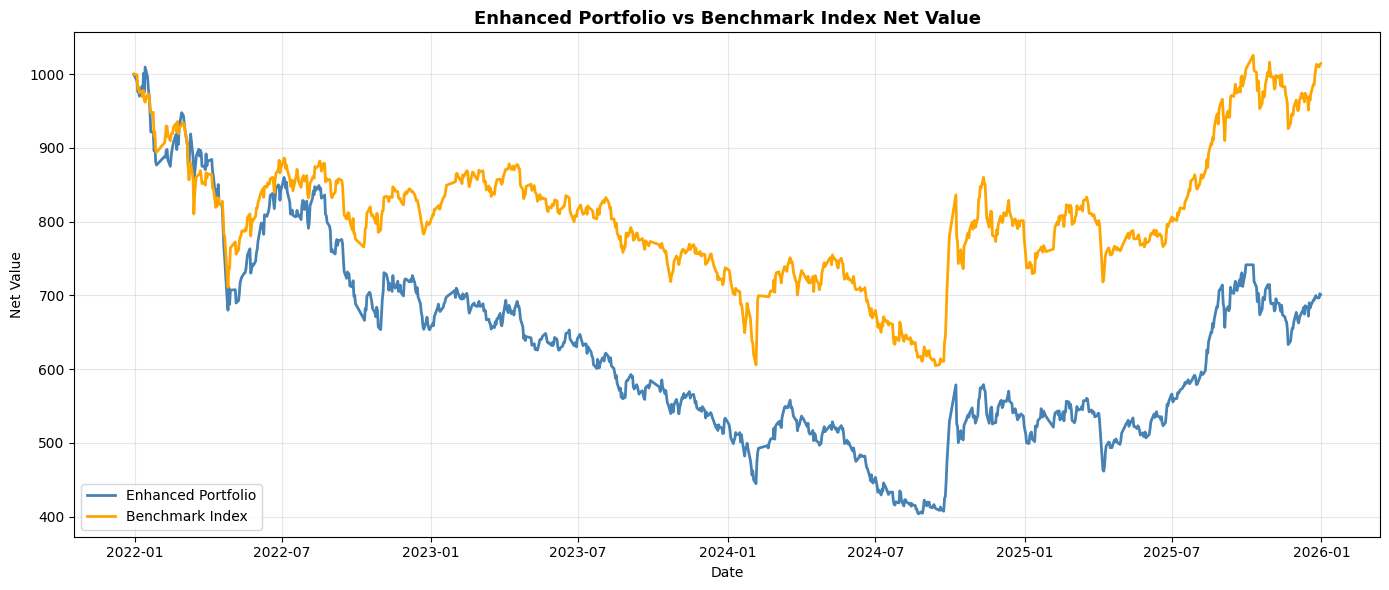

In [15]:
def normalize_nav(series, base=1000):
    """把净值或价格序列统一标准化到 base。"""
    series = series.dropna()
    return series / series.iloc[0] * base

# 绘制净值曲线
fig, ax = plt.subplots(figsize=(14, 6))

benchmark_price = rq.get_price('000905.XSHG', start_date, end_date, '1d', 'close').droplevel(0)
enhanced_nav = normalize_nav(enhance_value, initial_nav)
benchmark_nav = normalize_nav(benchmark_price, initial_nav)

ax.plot(enhanced_nav.index, enhanced_nav.values, linewidth=2, label='Enhanced Portfolio', color='steelblue')
ax.plot(benchmark_nav.index, benchmark_nav.values, linewidth=2, label='Benchmark Index', color='orange')
ax.set_title('Enhanced Portfolio vs Benchmark Index Net Value', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Net Value')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [16]:
def calc_drawdown_series(nav):
    """计算回撤序列。"""
    cummax = nav.cummax()
    return (nav - cummax) / cummax


def calculate_performance(port_value, daily_pnl, risk_free_rate=0.03):
    """计算绩效指标。"""
    daily_returns = port_value.pct_change().dropna()
    annual_return = (port_value.iloc[-1] / port_value.iloc[0]) ** (252 / len(port_value)) - 1
    annual_volatility = daily_returns.std() * np.sqrt(252)
    sharpe_ratio = np.nan if annual_volatility == 0 else (annual_return - risk_free_rate) / annual_volatility
    max_drawdown = calc_drawdown_series(port_value).min()
    win_rate = np.nan if len(daily_pnl) == 0 else (daily_pnl > 0).sum() / len(daily_pnl)

    return {
        '年化收益率': annual_return,
        '年化波动率': annual_volatility,
        '夏普比率': sharpe_ratio,
        '最大回撤': max_drawdown,
        '胜率': win_rate,
    }


In [17]:
performance = calculate_performance(enhance_value, daily_pnl)

print("\n绩效指标:")
print("=" * 40)
for key, value in performance.items():
    if key == '胜率':
        print(f"{key}: {value:.2%}")
    elif key == '最大回撤':
        print(f"{key}: {value:.2%}")
    else:
        print(f"{key}: {value:.4f}")


绩效指标:
年化收益率: -0.0881
年化波动率: 0.2608
夏普比率: -0.4529
最大回撤: -59.99%
胜率: 48.40%


## Step 7: 市场中性策略构建

使用 IC 主力合约对冲 beta 风险，并处理合约到期前展期。

In [18]:
#提取回测期间的所有主力合约
IC_dominant=rq.futures.get_dominant('IC',start_date,end_date)

# 获取历史主力合约的详细信息：到期日
IC_list=np.unique(IC_dominant.values).tolist()
TI=rq.instruments(IC_list)

#取所有合约的历史价格
T=rq.get_price(IC_list,start_date,end_date,'1d',expect_df=True)
print(T.head())
print(benchmark_price.head())

#合并价格信息与到期日
T["maturity_date"]=None
for IC in IC_list:
    T.loc[IC,"maturity_date"]=pd.Timestamp(TI[IC_list.index(IC)].maturity_date)
T["t_maturity"]=(pd.to_datetime(T.maturity_date)-pd.to_datetime(T.index.get_level_values(1))).map(lambda x:x.days)

                          settlement     low   close  prev_settlement  \
order_book_id date                                                      
IC2201        2021-12-31      7377.8  7344.0  7371.8           7336.2   
              2022-01-04      7365.6  7317.8  7371.0           7377.8   
              2022-01-05      7232.6  7214.4  7221.8           7365.6   
              2022-01-06      7227.2  7167.6  7225.2           7232.6   
              2022-01-07      7198.0  7183.0  7192.0           7227.2   

                          limit_down  prev_close    open  open_interest  \
order_book_id date                                                        
IC2201        2021-12-31      6602.6      7342.8  7344.0        93717.0   
              2022-01-04      6640.2      7371.8  7397.0        92724.0   
              2022-01-05      6629.2      7371.0  7360.0        94931.0   
              2022-01-06      6509.4      7221.8  7195.6        86111.0   
              2022-01-07      6504.6  

In [ ]:
def hedged_returns(long_value,T,rebalance_dates,IC_dominant):
    state={}
    port_value={}
    state["value"]=100
    for date in long_value.index.values:
        hedge_contract = state.get("hedge_contract")
        
        if date>rebalance_dates[0]:
            prev_date=long_value.index.values[long_value.index.get_loc(date)-1]
            state["value"]=state["value"]+state["long"]*long_value.diff().loc[date]\
            -state["short"]*(T.loc[hedge_contract, date].close-T.loc[hedge_contract, prev_date].close)
        
        if date in rebalance_dates:
            state["long"]=state["value"]/long_value.loc[date]
            state["hedge_contract"]=IC_dominant[date]
            # 检查调仓日是否有期货数据
            hedge_contract = IC_dominant[date]
            state["short"]=state["value"]/T.loc[hedge_contract, date].close
        
        # 展期
        hedge_contract = state.get("hedge_contract")
        if hedge_contract is not None and (hedge_contract, date) in T.index:
            if T.loc[hedge_contract, date].t_maturity<2: # 不在最后一天展期
                next_date=long_value.index.values[long_value.index.get_loc(date)+1]
                state["hedge_contract"]=IC_dominant[next_date] # 假设只做展期，但合约数量不发生变化
        
        port_value[date]=state.get("value",np.nan)
    
    return port_value

In [ ]:
T.index = T.index.set_levels(pd.to_datetime(T.index.levels[1]), level=1)
rebalance_dates = get_rebalance_dates(
    enhance_value.index[0].date(), 
    enhance_value.index[-1].date(), 
    'm'
)
rebalance_dates = [pd.to_datetime(rebalance_date) for rebalance_date in rebalance_dates]
enhanced_value_hedged = hedged_returns(enhance_value, T, rebalance_dates, rebalance_dates,IC_dominant)


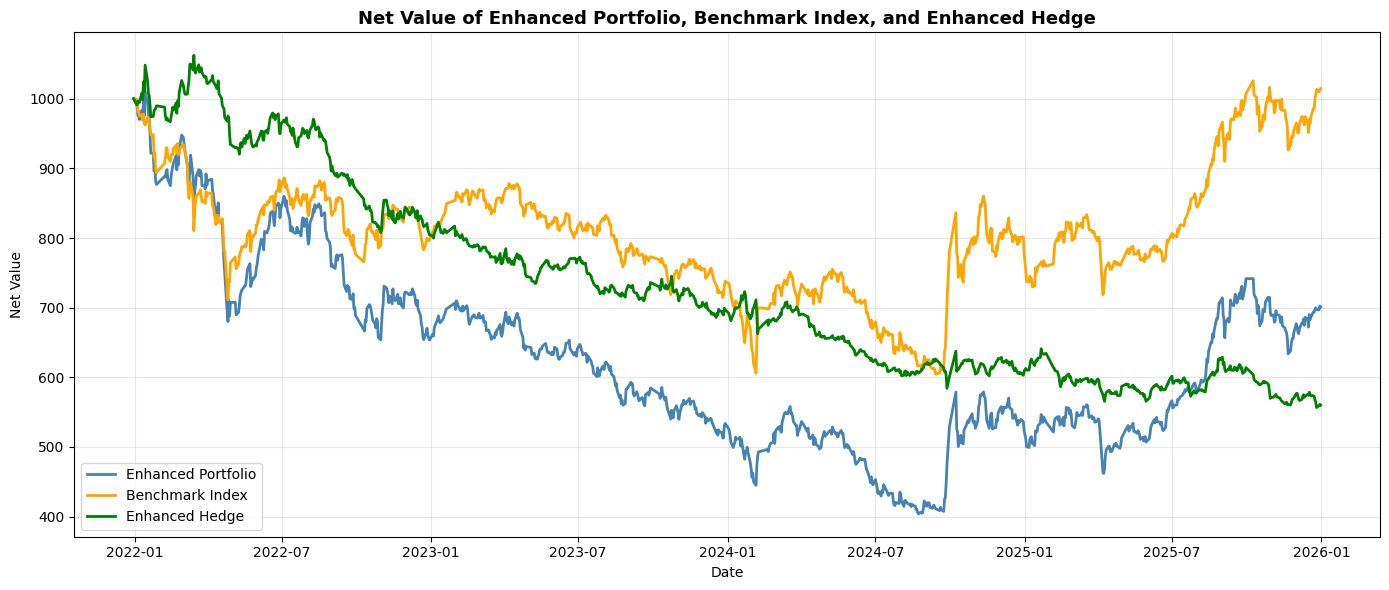

In [21]:
# 绘制净值曲线
fig, ax = plt.subplots(figsize=(14, 6))

enhanced_hedge_nav = normalize_nav(pd.Series(enhanced_value_hedged), initial_nav)

ax.plot(enhanced_nav.index, enhanced_nav.values, linewidth=2, label='Enhanced Portfolio', color='steelblue')
ax.plot(benchmark_nav.index, benchmark_nav.values, linewidth=2, label='Benchmark Index', color='orange')
ax.plot(enhanced_hedge_nav.index, enhanced_hedge_nav.values, linewidth=2, label='Enhanced Hedge', color='green')
ax.set_title('Net Value of Enhanced Portfolio, Benchmark Index, and Enhanced Hedge', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Net Value')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
def calculate_annualized_basis_cost(benchmark_price, dominant_contracts, futures_data):
    """计算整个回测期间的平均年化基差成本。"""
    
    # 确保基准价格的索引是 DatetimeIndex
    benchmark_price.index = pd.to_datetime(benchmark_price.index)
    
    # 获取所有交易日
    trade_dates = benchmark_price.index.intersection(dominant_contracts.index)
    
    basis_costs = []
    
    
    for date in trade_dates:
        # 获取当天的指数价格
        spot_price = float(benchmark_price.loc[date])
        # 获取当天的主力合约
        contract_id = dominant_contracts.loc[date]
        
        # 获取期货数据
        if contract_id in futures_data.index.get_level_values(0):
            futures_info = futures_data.loc[(contract_id, date)]
            future_price = futures_info['close']
            days_to_maturity = futures_info['t_maturity']
            
            # 避免除以零
            if days_to_maturity > 0 and spot_price > 0:
                # 计算年化基差
                annualized_basis = ((future_price - spot_price) / spot_price) * (365 / days_to_maturity)
                basis_costs.append(annualized_basis)

    # 计算平均年化基差成本
    if basis_costs:
        average_cost = np.mean(basis_costs)
    else:
        average_cost = 0
        
    return average_cost, basis_costs

# 计算并输出基差成本
avg_basis_cost, basis_costs = calculate_annualized_basis_cost(benchmark_price, IC_dominant, T)

print("基差计算完成:")
print("=" * 40)
print(f"  平均年化基差（对冲成本）: {avg_basis_cost:.2%}")
print("=" * 40)


基差计算完成:
  平均年化基差（对冲成本）: -7.12%


## Step 8：基差预测模型

In [46]:
def get_monthly_rebalance_dates(start_date, end_date):
    """生成月度调仓日期列表（每月最后一个交易日）。"""
    return get_rebalance_dates(start_date, end_date, freq='monthly')

def build_prediction_dataset(basis_ann, spot_px, ic_px, horizon=21):
    """
    构造预测数据集。
    X1 = ln(F/S)
    X2 = 期货 20 日波动率 sigma_F
    X3 = 现货 20 日波动率 sigma_S
    y  = horizon 个交易日后的年化基差波动率
    """
    common_dates = ic_px.index.intersection(spot_px.index).intersection(basis_ann.index)
    df = pd.DataFrame(index=common_dates)
    
    basis = (ic_px - spot_px) / spot_px.reindex(common_dates)
    df["X1_basis_volatility"] = basis.pct_change().rolling(20).std().reindex(common_dates)
    df["X2_sigma_F"] = ic_px.pct_change().rolling(20).std().reindex(common_dates)
    df["X3_sigma_S"] = spot_px.pct_change().rolling(20).std().reindex(common_dates)
    df = df.dropna()

    basis_ann = basis_ann.sort_index()
    future_basis = basis_ann.shift(-horizon)
    df["y_future_volatility"] = future_basis.reindex(df.index).pct_change().rolling(20).std()
    q_low = df["y_future_volatility"].quantile(0.20)
    q_high = df["y_future_volatility"].quantile(0.80)
    df = df[(df["y_future_volatility"] >= q_low) & (df["y_future_volatility"] <= q_high)]
    df["y_future_volatility"] = df["y_future_volatility"].fillna(df["y_future_volatility"].median())
    
    return df.dropna(subset=["y_future_volatility"])


print("工具函数定义完成")


工具函数定义完成


## Step 9：滚动 OLS 预测 + 决策映射

In [ ]:
def predict_and_decide(val_date, dataset, lookback=756):
    """
    在给定月度调仓日 val_date：
    1. 用过去 lookback 天数据做滚动 OLS
    2. 预测 basis_pred
    3. 用训练集历史分位映射为对冲比例
    """
    train_data = dataset[dataset.index < pd.to_datetime(val_date)].tail(lookback)
    if len(train_data) < 100:
        return 1.0

    feature_cols = ["X1_basis_volatility", "X2_sigma_F", "X3_sigma_S"]
    X_train = train_data[feature_cols].values
    y_train = train_data["y_future_volatility"].values

    current = dataset[dataset.index <= pd.to_datetime(val_date)].tail(1)
    if len(current) == 0:
        return 1.0
    X_current = current[feature_cols].values.reshape(1, -1)

    model = LinearRegression()

    model.fit(X_train, y_train)
    basis_pred = model.predict(X_current)[0]
    

    historical_basis_volatility = train_data["y_future_volatility"].dropna()
    
    p_pred = (historical_basis_volatility < basis_pred).sum() / len(historical_basis_volatility)
    p_pred = np.clip(p_pred, 0.0, 1.0)

    alpha = 2.0
    w = 1 - p_pred ** alpha
    
    
    return w

print("预测+决策函数定义完成")

预测+决策函数定义完成


In [101]:
def hedged_returns_dynamic(long_value, ic_px, stock_rebalance_dates, hedge_ratios, futures_rebalance_dates):
    """
    动态对冲策略：根据预测的对冲比例调整对冲仓位。
    
    参数:
    - long_value: 多头组合净值序列
    - ic_px: IC主力合约价格序列
    - stock_rebalance_dates: 股票调仓日期（半年调仓）
    - hedge_ratios: 各期货调仓日的对冲比例字典
    - futures_rebalance_dates: 期货调仓日期（月度调仓）
    """
    state = {}
    port_value = {}
    state["value"] = 100
    state["hedge_ratio"] = 1.0  # 初始对冲比例
    
    for date in long_value.index.values:
        if date > stock_rebalance_dates[0]:
            prev_date = long_value.index.values[long_value.index.get_loc(date) - 1]
            # 计算对冲收益
            hedge_pnl = state["short"] * (ic_px.loc[date] - ic_px.loc[prev_date])
            state["value"] = state["value"] + state["long"] * long_value.diff().loc[date] - hedge_pnl
        
        # 股票调仓日：调整多头仓位
        if date in stock_rebalance_dates:
            state["long"] = state["value"] / long_value.loc[date]
        
        # 期货调仓日：调整对冲比例和空头仓位
        if date in futures_rebalance_dates:
            state["hedge_ratio"] = hedge_ratios[-1]
            # 根据对冲比例调整空头仓位
            if state["hedge_ratio"] > 0:
                state["short"] = state["value"] * state["hedge_ratio"] / ic_px.loc[date]
            else:
                state["short"] = 0
        
        port_value[date] = state.get("value", np.nan)
    
    return pd.Series(port_value)

print("动态对冲函数定义完成")


动态对冲函数定义完成


In [105]:
IC_dominant_px = pd.Series(index=IC_dominant.index, dtype=float)
for date, contract_id in IC_dominant.items():
    if (contract_id, date) in T.index:
        IC_dominant_px[date] = T.loc[(contract_id, date), 'close']
IC_dominant_px = IC_dominant_px.dropna()

basis_ann_series = pd.Series(basis_costs, index=benchmark_price.index[-len(basis_costs):])
# 使用每日主力合约的价格序列，而不是包含所有合约价格的序列
prediction_dataset = build_prediction_dataset(basis_ann_series, enhance_value, IC_dominant_px)

# 获取月度调仓日
monthly_rebalance_dates = get_monthly_rebalance_dates(start_date, end_date)
monthly_rebalance_dates_dt = [pd.to_datetime(d) for d in monthly_rebalance_dates]

# 为每个月度调仓日计算对冲比例
hedge_ratios = []
for date in monthly_rebalance_dates:
    hedge_ratios.append(predict_and_decide(date, prediction_dataset))

enhanced_hedge_dynamic_value = hedged_returns_dynamic(
    enhance_value, 
    IC_dominant_px, 
    rebalance_dates, # 股票半年调仓日
    hedge_ratios, 
    monthly_rebalance_dates_dt # 期货月度调仓日
)
print(f"平均多头敞口: {1-pd.Series(hedge_ratios).mean():.2%}")


平均多头敞口: 33.67%


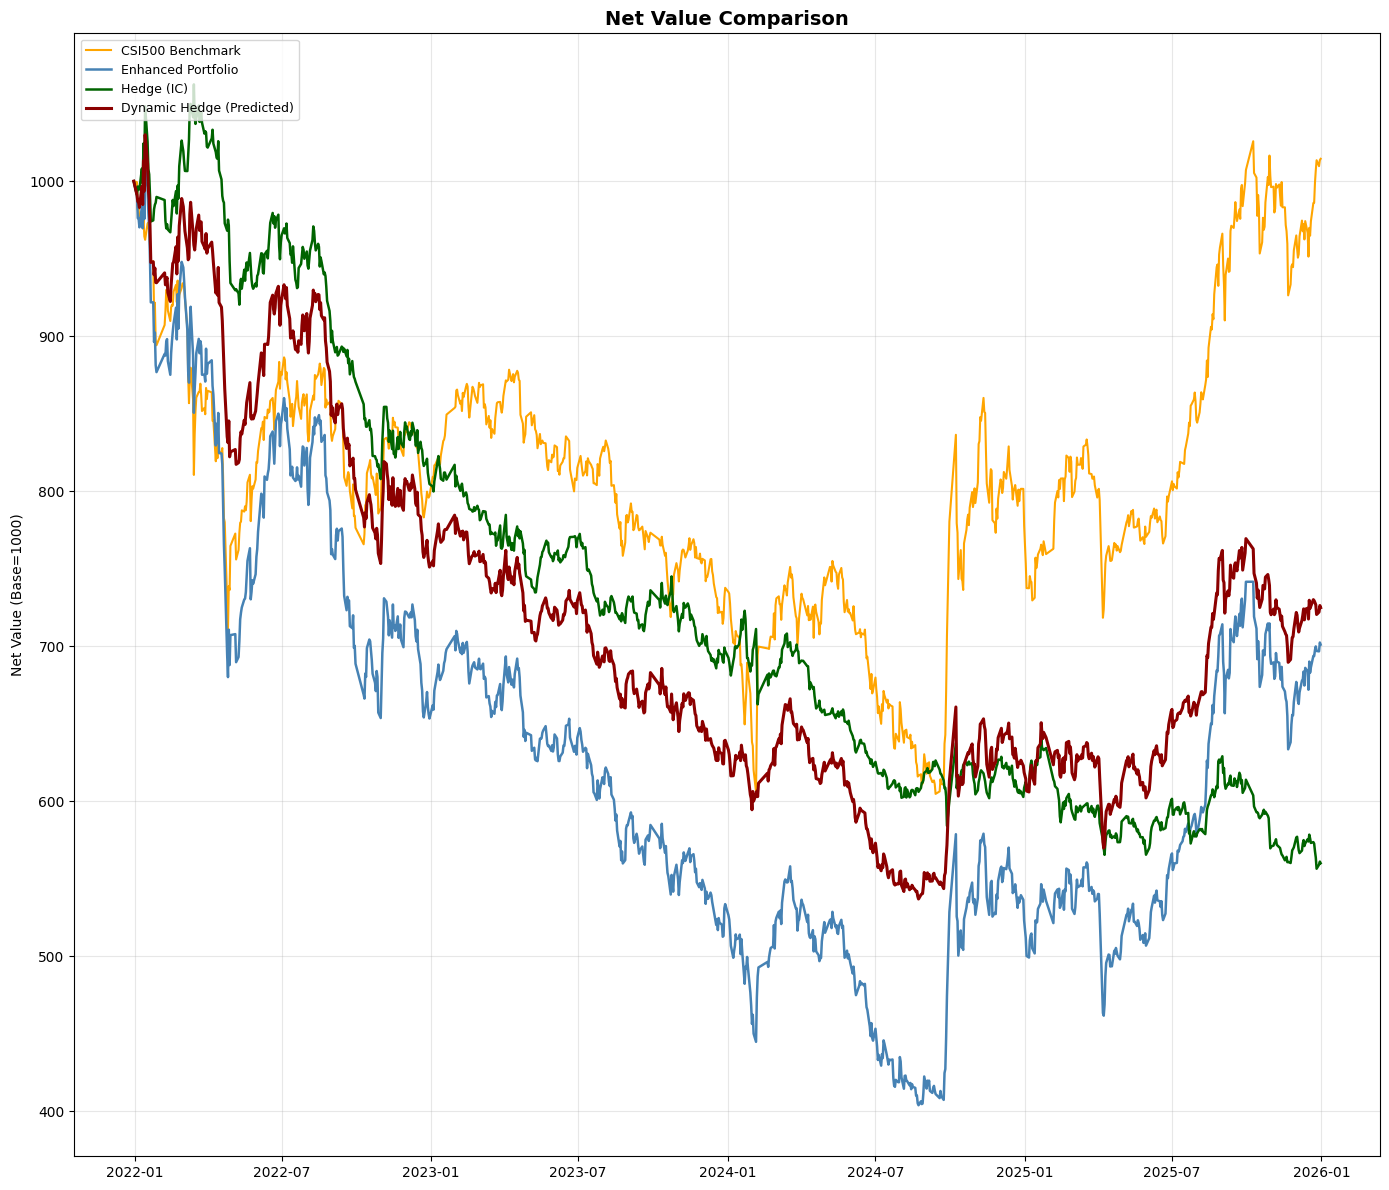

In [106]:
# ============================================================
# 可视化对比：指数 | 增强 | 对冲 | 动态对冲
# ============================================================
fig, axes = plt.subplots(figsize=(14, 12))

dynamic_hedge_nav = normalize_nav(enhanced_hedge_dynamic_value, initial_nav)

axes.plot(benchmark_nav.index, benchmark_nav.values,
          label="CSI500 Benchmark", color="orange", linewidth=1.5)
axes.plot(enhanced_nav.index, enhanced_nav.values,
          label="Enhanced Portfolio", color="steelblue", linewidth=1.8)
axes.plot(enhanced_hedge_nav.index, enhanced_hedge_nav.values,
          label="Hedge (IC)", color="darkgreen", linewidth=1.8)
axes.plot(dynamic_hedge_nav.index, dynamic_hedge_nav.values,
          label="Dynamic Hedge (Predicted)", color="darkred", linewidth=2.2)
axes.set_title("Net Value Comparison", fontsize=14, fontweight="bold")
axes.set_ylabel("Net Value (Base=1000)")
axes.legend(fontsize=9, loc="upper left")
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Step 10：策略表现对比

In [79]:
def calculate_nav_performance(nav_series, risk_free_rate=0.03):
    """
    从净值序列计算绩效指标。
    """
    # 确保 nav_series 是一个 Series
    if not isinstance(nav_series, pd.Series):
        nav_series = pd.Series(nav_series)
        
    daily_returns = nav_series.pct_change().dropna()
    
    # 如果没有足够的数据点，返回空指标
    if len(nav_series) < 2 or len(daily_returns) == 0:
        return {
            '年化收益率': 0,
            '年化波动率': 0,
            '夏普比率': 0,
            '最大回撤': 0
        }

    # 计算年化收益率
    annual_return = (nav_series.iloc[-1] / nav_series.iloc[0]) ** (252 / len(nav_series)) - 1
    
    # 计算年化波动率
    annual_volatility = daily_returns.std() * np.sqrt(252)
    
    # 计算夏普比率
    sharpe_ratio = (annual_return - risk_free_rate) / annual_volatility if annual_volatility != 0 else 0
    
    # 计算最大回撤
    max_drawdown = calc_drawdown_series(nav_series).min()

    return {
        '年化收益率': annual_return,
        '年化波动率': annual_volatility,
        '夏普比率': sharpe_ratio,
        '最大回撤': max_drawdown
    }

# 准备要评估的组合
portfolios = {
    "基准指数": benchmark_nav.squeeze(),
    "增强组合": enhanced_nav,
    "完全对冲": enhanced_hedge_nav,
    "动态对冲": dynamic_hedge_nav
}


# 计算每个组合的绩效
performance_results = {}
for name, nav in portfolios.items():
    performance_results[name] = calculate_nav_performance(nav, risk_free_rate)

# 将结果转换为DataFrame以便于比较
df_performance = pd.DataFrame(performance_results).T

# 格式化输出
df_performance_formatted = df_performance.copy()
df_performance_formatted['年化收益率'] = df_performance_formatted['年化收益率'].map('{:.2%}'.format)
df_performance_formatted['年化波动率'] = df_performance_formatted['年化波动率'].map('{:.2%}'.format)
df_performance_formatted['夏普比率'] = df_performance_formatted['夏普比率'].map('{:.2f}'.format)
df_performance_formatted['最大回撤'] = df_performance_formatted['最大回撤'].map('{:.2%}'.format)

print("各策略绩效对比:")
print("=" * 50)
print(df_performance_formatted[['夏普比率', '最大回撤','年化收益率', '年化波动率']])
print("=" * 50)

各策略绩效对比:
       夏普比率     最大回撤    年化收益率   年化波动率
基准指数  -0.07  -39.52%    0.37%  21.79%
增强组合  -0.41  -59.99%   -8.81%  26.08%
完全对冲  -1.24  -47.62%  -13.98%  12.84%
动态对冲  -0.80  -38.40%   -8.54%  13.21%


### 作业中存在的疑惑
如果我们设置w恒为常数（w!=1），发现策略表现没有改变；而当w=1时，平均多头敞口小于100%但表现与指数增强策略相同。其中的原因是什么呢？是否存在代码错误？恳请老师和助教指正。